<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QTF008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

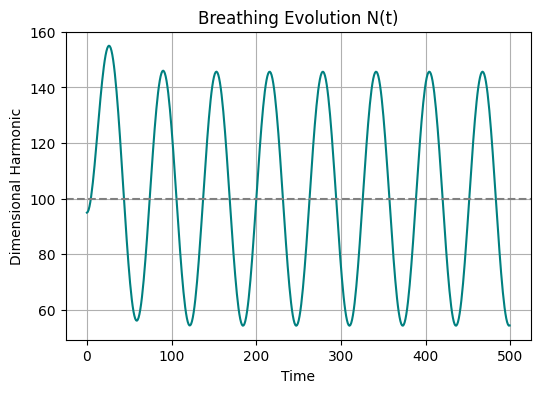

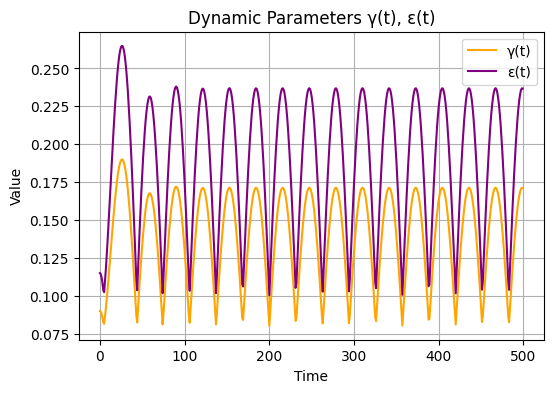

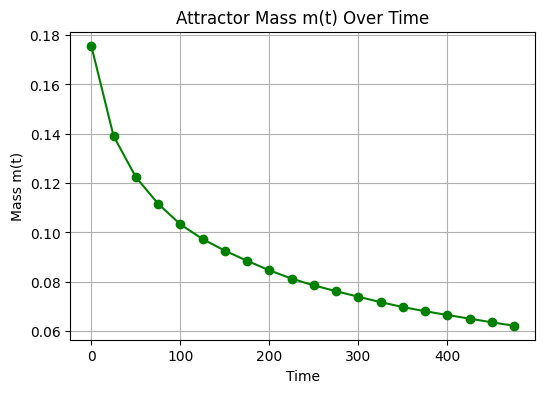

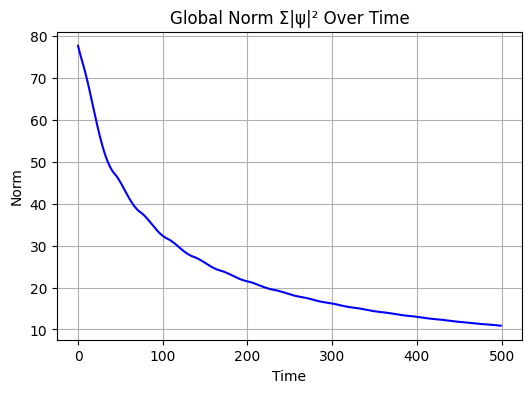

In [1]:
# QFT008: Dynamic Attractor Mass Oscillation
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Parameters
N_grid = 100
T = 500
dt = 1.0
gamma_0 = 0.08
epsilon_0 = 0.10
alpha = 0.002
beta = 0.003
kappa = 0.05
delta = 5.0
omega = 0.1

# Breathing evolution: N(t)
t_arr = np.arange(0, T, dt)
N_t = np.zeros_like(t_arr)
N_t[0] = 95.0
for i in range(1, T):
    dNdt = -kappa * (N_t[i-1] - 100) + delta * np.sin(omega * t_arr[i-1])
    N_t[i] = N_t[i-1] + dt * dNdt

# Dynamic γ(t), ε(t)
delta_N = np.abs(N_t - 100)
gamma_t = gamma_0 + alpha * delta_N
epsilon_t = epsilon_0 + beta * delta_N

# Seed initialization
x0, y0 = N_grid//2, N_grid//2
X, Y = np.meshgrid(np.arange(N_grid), np.arange(N_grid))
psi = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * 5.0**2)) + 1j * np.zeros((N_grid, N_grid))

# FFT Laplacian kernel
kx = np.fft.fftfreq(N_grid).reshape((N_grid, 1))
ky = np.fft.fftfreq(N_grid).reshape((1, N_grid))
laplacian_kernel = -4 * np.pi**2 * (kx**2 + ky**2)

# Track mass and norm
mass_list = []
norm_list = []

# Evolution loop
for t in range(T):
    gamma = gamma_t[t]
    epsilon = epsilon_t[t]
    implicit_denominator = 1 - gamma * laplacian_kernel

    delta_A2 = (
        np.roll(np.abs(psi)**2, 1, axis=0) + np.roll(np.abs(psi)**2, -1, axis=0)
        - 2 * np.abs(psi)**2
    )
    compensation = epsilon * delta_A2
    rhs = psi + compensation
    rhs_fft = np.fft.fft2(rhs)
    psi_new_fft = rhs_fft / implicit_denominator
    psi = np.fft.ifft2(psi_new_fft)

    norm_list.append(np.sum(np.abs(psi)**2))

    if t % 25 == 0:
        magnitude = np.abs(psi)**2
        radii = []
        values = []
        for r in range(1, N_grid//2):
            shell = magnitude[x0-r:x0+r+1, y0-r:y0+r+1]
            shell_mean = np.mean(shell)
            radii.append(r)
            values.append(shell_mean)
        try:
            params, _ = curve_fit(lambda r, a, l: a * np.exp(-r / l), radii, values, p0=(1.0, 10.0))
            lambda_c = params[1]
            mass_list.append(1 / lambda_c)
        except:
            mass_list.append(np.nan)

# Plot N(t)
plt.figure(figsize=(6, 4))
plt.plot(t_arr, N_t, label='N(t)', color='teal')
plt.axhline(100, color='gray', linestyle='--')
plt.title('Breathing Evolution N(t)')
plt.xlabel('Time')
plt.ylabel('Dimensional Harmonic')
plt.grid(True)
plt.show()

# Plot γ(t), ε(t)
plt.figure(figsize=(6, 4))
plt.plot(t_arr, gamma_t, label='γ(t)', color='orange')
plt.plot(t_arr, epsilon_t, label='ε(t)', color='purple')
plt.title('Dynamic Parameters γ(t), ε(t)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot Mass m(t)
plt.figure(figsize=(6, 4))
plt.plot(np.arange(0, T, 25), mass_list, marker='o', color='green')
plt.title('Attractor Mass m(t) Over Time')
plt.xlabel('Time')
plt.ylabel('Mass m(t)')
plt.grid(True)
plt.show()

# Plot Norm
plt.figure(figsize=(6, 4))
plt.plot(norm_list, color='blue')
plt.title('Global Norm Σ|ψ|² Over Time')
plt.xlabel('Time')
plt.ylabel('Norm')
plt.grid(True)
plt.show()
